# Data engineering

In [4]:
import pandas as pd
df = pd.read_csv("dataset_incendi_FIRMS.csv")

/tmp/ipykernel_59827/1607493755.py:2: DtypeWarning: Columns (0: instrument, 1: confidence, 2: version) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_incendi_FIRMS.csv")


In [5]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,frp,daynight,dataset,chunk_start,chunk_end,type,bright_ti4,bright_ti5,path,row
0,37.11722,49.82455,308.68,1.00,1.00,2026-01-01,9,Aqua,MODIS,75,...,12.23,N,MODIS_NRT,2025-12-31,2026-01-01,NaN,NaN,NaN,NaN,NaN
1,-25.37589,123.11378,329.29,2.07,1.40,2026-01-01,11,Terra,MODIS,76,...,38.36,D,MODIS_NRT,2025-12-31,2026-01-01,NaN,NaN,NaN,NaN,NaN
2,-25.36225,123.12387,324.47,2.07,1.40,2026-01-01,11,Terra,MODIS,66,...,21.46,D,MODIS_NRT,2025-12-31,2026-01-01,NaN,NaN,NaN,NaN,NaN
3,30.36209,47.33912,318.51,1.02,1.01,2026-01-01,11,Aqua,MODIS,97,...,22.14,N,MODIS_NRT,2025-12-31,2026-01-01,NaN,NaN,NaN,NaN,NaN
4,30.39269,49.86965,314.71,1.06,1.03,2026-01-01,11,Aqua,MODIS,90,...,19.04,N,MODIS_NRT,2025-12-31,2026-01-01,NaN,NaN,NaN,NaN,NaN


In [7]:
df.shape

(11682021, 22)

# Elimino tutte le colonne completamente vuote

In [8]:
import pandas as pd

df = pd.read_csv("dataset_incendi_FIRMS.csv")

end_col = df.columns.get_loc("chunk_end")

df = df.iloc[:, :end_col + 1]
df.head()

/tmp/ipykernel_59827/702116687.py:3: DtypeWarning: Columns (0: instrument, 1: confidence, 2: version) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_incendi_FIRMS.csv")


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,dataset,chunk_start,chunk_end
0,37.11722,49.82455,308.68,1.00,1.00,2026-01-01,9,Aqua,MODIS,75,6.1NRT,281.47,12.23,N,MODIS_NRT,2025-12-31,2026-01-01
1,-25.37589,123.11378,329.29,2.07,1.40,2026-01-01,11,Terra,MODIS,76,6.1NRT,304.07,38.36,D,MODIS_NRT,2025-12-31,2026-01-01
2,-25.36225,123.12387,324.47,2.07,1.40,2026-01-01,11,Terra,MODIS,66,6.1NRT,304.35,21.46,D,MODIS_NRT,2025-12-31,2026-01-01
3,30.36209,47.33912,318.51,1.02,1.01,2026-01-01,11,Aqua,MODIS,97,6.1NRT,276.94,22.14,N,MODIS_NRT,2025-12-31,2026-01-01
4,30.39269,49.86965,314.71,1.06,1.03,2026-01-01,11,Aqua,MODIS,90,6.1NRT,278.23,19.04,N,MODIS_NRT,2025-12-31,2026-01-01


# Controllo valori nulli

In [9]:
print(df.isna().sum())

latitude              0
longitude             0
brightness     10640351
scan                  0
track                 0
acq_date              0
acq_time              0
satellite             0
instrument       291653
confidence            0
version          258317
bright_t31     10640351
frp              258317
daynight              0
dataset               0
chunk_start           0
chunk_end             0
dtype: int64


In [10]:
df = df.dropna()
print(df.isna().sum())

latitude       0
longitude      0
brightness     0
scan           0
track          0
acq_date       0
acq_time       0
satellite      0
instrument     0
confidence     0
version        0
bright_t31     0
frp            0
daynight       0
dataset        0
chunk_start    0
chunk_end      0
dtype: int64


In [11]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,dataset,chunk_start,chunk_end
0,37.11722,49.82455,308.68,1.00,1.00,2026-01-01,9,Aqua,MODIS,75,6.1NRT,281.47,12.23,N,MODIS_NRT,2025-12-31,2026-01-01
1,-25.37589,123.11378,329.29,2.07,1.40,2026-01-01,11,Terra,MODIS,76,6.1NRT,304.07,38.36,D,MODIS_NRT,2025-12-31,2026-01-01
2,-25.36225,123.12387,324.47,2.07,1.40,2026-01-01,11,Terra,MODIS,66,6.1NRT,304.35,21.46,D,MODIS_NRT,2025-12-31,2026-01-01
3,30.36209,47.33912,318.51,1.02,1.01,2026-01-01,11,Aqua,MODIS,97,6.1NRT,276.94,22.14,N,MODIS_NRT,2025-12-31,2026-01-01
4,30.39269,49.86965,314.71,1.06,1.03,2026-01-01,11,Aqua,MODIS,90,6.1NRT,278.23,19.04,N,MODIS_NRT,2025-12-31,2026-01-01


# Conversione date

In [12]:
df["acq_date"] = pd.to_datetime(df["acq_date"])
df["chunk_start"] = pd.to_datetime(df["chunk_start"])
df["chunk_end"] = pd.to_datetime(df["chunk_end"])
print(df["acq_date"])
print(df["chunk_start"])
print(df["chunk_end"])

0         2026-01-01
1         2026-01-01
2         2026-01-01
3         2026-01-01
4         2026-01-01
             ...    
1041665   2025-05-17
1041666   2025-05-17
1041667   2025-05-17
1041668   2025-05-17
1041669   2025-05-17
Name: acq_date, Length: 1041670, dtype: datetime64[us]
0         2025-12-31
1         2025-12-31
2         2025-12-31
3         2025-12-31
4         2025-12-31
             ...    
1041665   2025-05-15
1041666   2025-05-15
1041667   2025-05-15
1041668   2025-05-15
1041669   2025-05-15
Name: chunk_start, Length: 1041670, dtype: datetime64[us]
0         2026-01-01
1         2026-01-01
2         2026-01-01
3         2026-01-01
4         2026-01-01
             ...    
1041665   2025-05-16
1041666   2025-05-16
1041667   2025-05-16
1041668   2025-05-16
1041669   2025-05-16
Name: chunk_end, Length: 1041670, dtype: datetime64[us]


# Matrice di correlazione

            latitude  longitude  brightness      scan     track  acq_time  \
latitude    1.000000   0.139997   -0.138150 -0.016608 -0.014796 -0.181403   
longitude   0.139997   1.000000   -0.058156 -0.024055 -0.024130 -0.547685   
brightness -0.138150  -0.058156    1.000000 -0.062934 -0.065121  0.087145   
scan       -0.016608  -0.024055   -0.062934  1.000000  0.988241 -0.000626   
track      -0.014796  -0.024130   -0.065121  0.988241  1.000000 -0.000731   
acq_time   -0.181403  -0.547685    0.087145 -0.000626 -0.000731  1.000000   
bright_t31 -0.274494  -0.064192    0.499684 -0.124032 -0.126601  0.145155   
frp        -0.039657  -0.018579    0.592374  0.245992  0.241705  0.013255   

            bright_t31       frp  
latitude     -0.274494 -0.039657  
longitude    -0.064192 -0.018579  
brightness    0.499684  0.592374  
scan         -0.124032  0.245992  
track        -0.126601  0.241705  
acq_time      0.145155  0.013255  
bright_t31    1.000000  0.109040  
frp           0.109040  1.

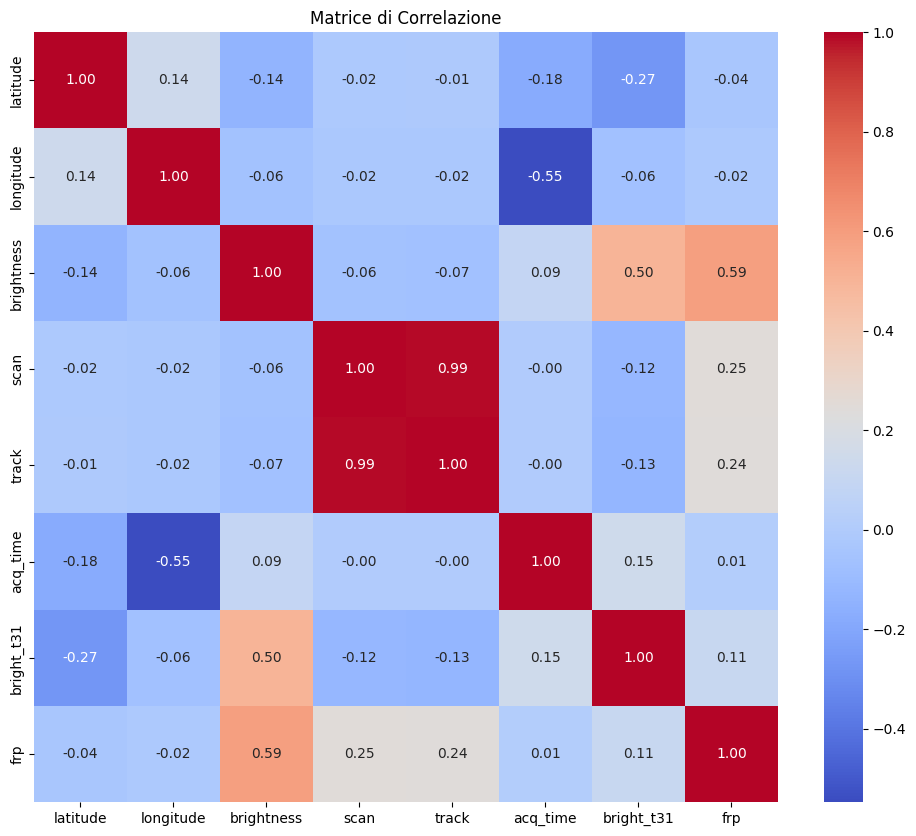

In [14]:
import numpy as np

corr = df.corr(numeric_only=True)
print(corr)

corr_pairs = (
    corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(10)
print(corr_pairs.head(10))

#plot della matrice di correlazione
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice di Correlazione")
plt.show()

In [15]:
# Bounding box Italia
df_italia = df[
    (df['longitude'] >= 6) &
    (df['longitude'] <= 19) &
    (df['latitude'] >= 36) &
    (df['latitude'] <= 47)
].copy()

print(df_italia)

         latitude  longitude  brightness  scan  track   acq_date  acq_time  \
7581     36.74208    6.26257      302.56  1.36   1.16 2026-01-02       847   
34192    36.74910    6.25338      302.81  1.01   1.00 2026-01-05       904   
39664    38.02549   14.94427      300.77  1.04   1.02 2026-01-05      1346   
39665    45.14048    9.94061      304.44  1.02   1.01 2026-01-05      1348   
62501    44.56487   11.98349      307.31  1.33   1.14 2026-01-07      1327   
...           ...        ...         ...   ...    ...        ...       ...   
1033449  46.74740    6.58040      330.80  1.00   1.00 2025-05-16      1340   
1035172  36.86830    6.97610      311.10  1.00   1.00 2025-05-16      2031   
1035173  36.86980    6.98700      311.20  1.00   1.00 2025-05-16      2031   
1038581  45.50020    9.39320      308.80  3.10   1.70 2025-05-17      1006   
1039511  40.41390   18.14300      331.80  1.40   1.20 2025-05-17      1239   

        satellite instrument confidence version  bright_t31    

In [16]:
df_italia.shape

(1255, 17)

In [ ]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df_italia,
    geometry=gpd.points_from_xy(df_italia.longitude, df_italia.latitude),
    crs="EPSG:4326"
)

<Axes: >

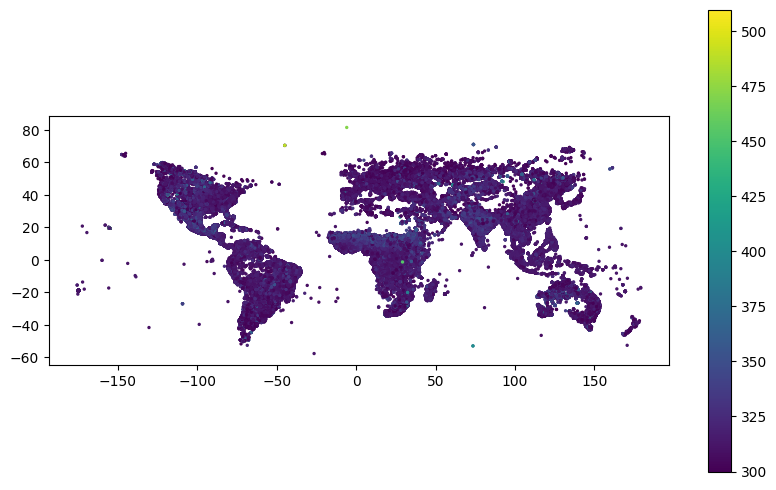

In [18]:
gdf.plot(column='brightness', figsize=(10, 6), legend=True, markersize=2)

In [ ]:
from IPython.display import display

m = gdf.explore(column="brightness", legend=True)